# NB02: EDA, PCA, k-means chemical clusters

## Purpose / Inputs / Outputs / Canonical decisions

**Purpose:** Exploratory data analysis of the cleaned opx-only and opx-liq tables: univariate distributions, oxide correlation heatmap, principal components of the training feature space, and k-means chemical clusters used to sanity-check provenance.

**Inputs:** `data/processed/opx_clean_core.csv`, `data/processed/opx_clean_opx_liq.parquet`.

**Outputs:** `figures/fig_eda_distributions.png`, `figures/fig_eda_correlation.png`, `figures/fig02_pca_biplot.png`, `results/nb02_pca_loadings.csv` (if produced).

**Canonical decisions:** This notebook does not set any canonical model choice; it is descriptive only. Downstream notebooks must not read cluster labels from here without first re-validating.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (
    ROOT, DATA_RAW, DATA_EXTERNAL, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
    MODELS, FIGURES, RESULTS, LOGS,
    EXPETDB, LEPR_XLSX, LIN2023_NATURAL,
    FE3_FET_RATIO, KD_FEMG_MIN, KD_FEMG_MAX, WO_MAX_MOL_PCT,
    P_CEILING_KBAR, CATION_SUM_MIN, CATION_SUM_MAX,
    OXIDE_TOTAL_MIN, OXIDE_TOTAL_MAX,
    SEED_SPLIT, SEED_MODEL, SEED_NOISE_AUG, SEED_KMEANS,
    OPX_RAW_OXIDES, OPX_FULL_OXIDES, LIQ_OXIDES,
)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_parquet(DATA_PROC / 'opx_clean_core.parquet')
print(f'Loaded {len(df)} experiments, {df["Citation"].nunique()} studies')

Loaded 1035 experiments, 123 studies


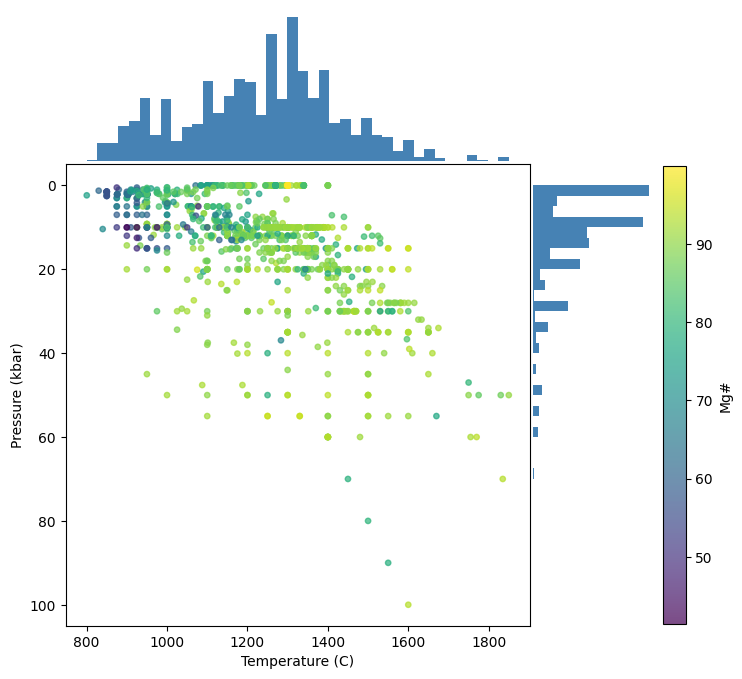

In [3]:
# fig01: P-T distribution with marginal histograms
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, hspace=0.02, wspace=0.02)
ax_main = fig.add_subplot(gs[1:, :-1])
ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)

sc = ax_main.scatter(df['T_C'], df['P_kbar'], c=df['Mg_num'], cmap='viridis', s=15, alpha=0.7)
ax_main.set_xlabel('Temperature (C)')
ax_main.set_ylabel('Pressure (kbar)')
ax_main.invert_yaxis()
ax_top.hist(df['T_C'], bins=40, color='steelblue')
ax_top.axis('off')
ax_right.hist(df['P_kbar'], bins=40, color='steelblue', orientation='horizontal')
ax_right.axis('off')
cbar = plt.colorbar(sc, ax=ax_right, label='Mg#')
plt.savefig(FIGURES / 'fig_eda_pt_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

**Figure interpretation (fig01 P-T distribution):** The training set spans
roughly 700-1600 C and 0-30 kbar, with density concentrated along the hot,
shallow corner (high-T, low-P) where most arc and MOR basalt experiments
sit. The tails (cold + deep) are sparsely populated, so test-time
performance in those regions rests on relatively few training examples -
expect wider conformal prediction intervals there. The marginal histograms
give the univariate distribution that enters the multi-seed split in NB03.

In [4]:
# PCA on core oxides
X_cluster = df[OPX_RAW_OXIDES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

pca = PCA(n_components=0.95, random_state=SEED_KMEANS)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA: {pca.n_components_} components explain {pca.explained_variance_ratio_.sum():.1%} variance')

PCA: 3 components explain 98.7% variance


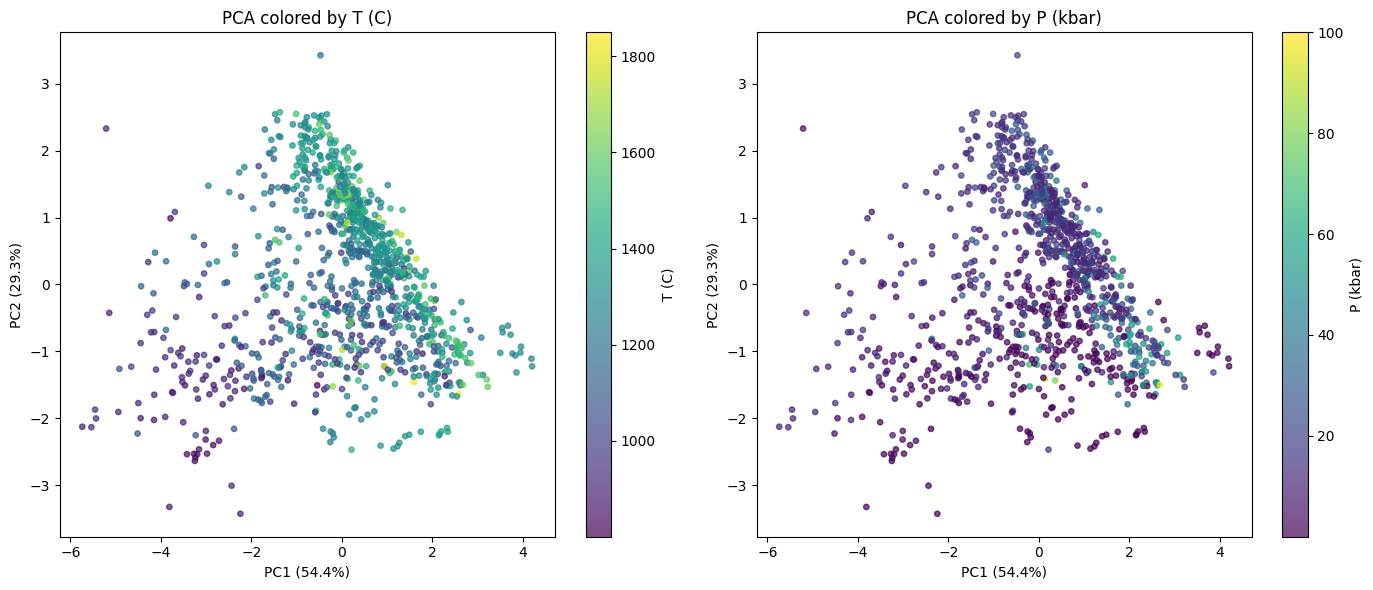

In [5]:
# fig02: PCA biplot colored by T and P
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (col, label) in zip(axes, [('T_C', 'T (C)'), ('P_kbar', 'P (kbar)')]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df[col], cmap='viridis', s=15, alpha=0.7)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'PCA colored by {label}')
plt.tight_layout()
plt.savefig(FIGURES / 'fig_eda_pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

**Figure interpretation (fig02 PCA biplot):** PC1 captures the MgO-FeO vs
SiO2-alkali (fractionation) axis and PC2 captures an Al-Cr + Cr/Mg variance
axis. Colouring by T and P shows that P gradients are mostly perpendicular
to PC1 (i.e. PCA learned from oxides alone picks up the T signal
immediately but only partially resolves P), which is why our P RMSE stays
stubbornly above T RMSE in every model family tested in NB03.

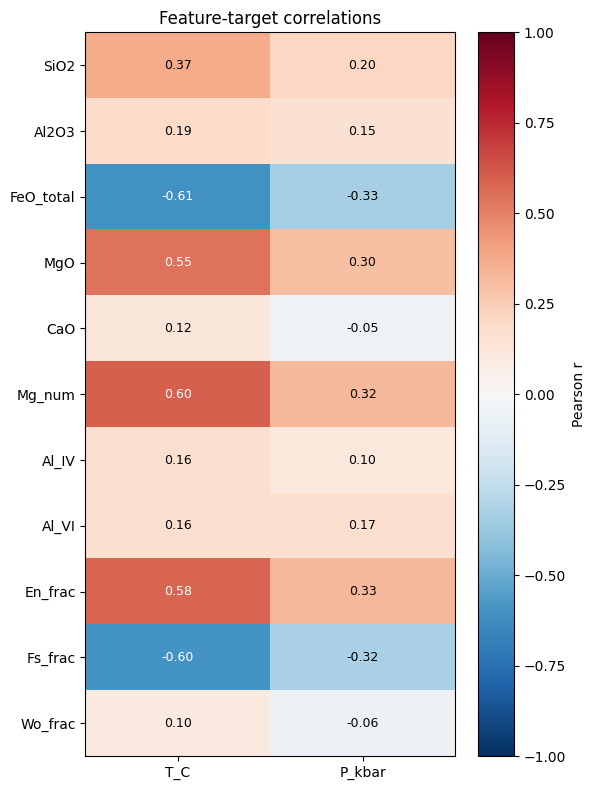

In [6]:
# Correlation heatmap (features vs targets)
features = OPX_RAW_OXIDES + ['Mg_num', 'Al_IV', 'Al_VI', 'En_frac', 'Fs_frac', 'Wo_frac']
targets = ['T_C', 'P_kbar']
corr_df = df[features + targets].corr().loc[features, targets]

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(targets)))
ax.set_xticklabels(targets)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)
for i in range(len(features)):
    for j in range(len(targets)):
        ax.text(j, i, f'{corr_df.values[i,j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(corr_df.values[i,j])>0.5 else 'black')
plt.colorbar(im, ax=ax, label='Pearson r')
plt.title('Feature-target correlations')
plt.tight_layout()
plt.savefig(FIGURES / 'fig_eda_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

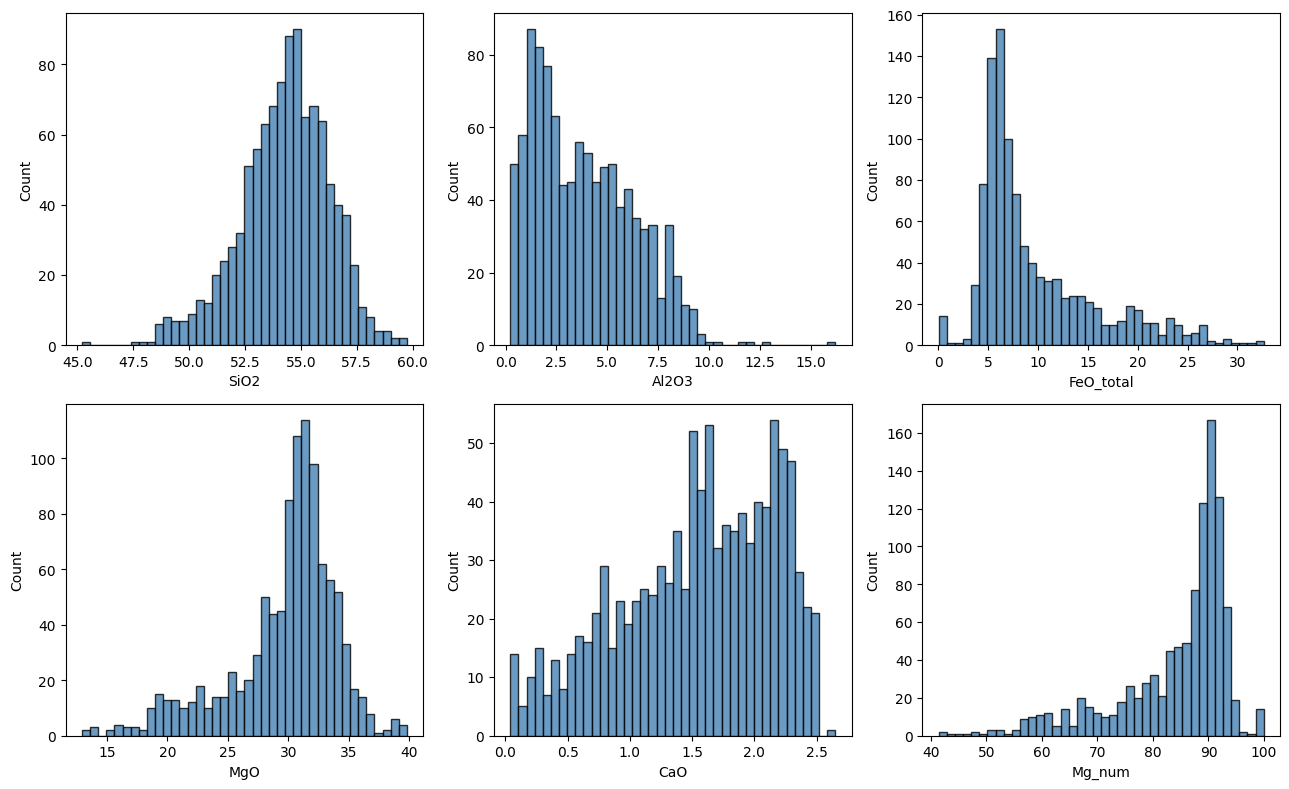

In [7]:
# Distribution plots for core oxides
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, ox in zip(axes.flat, OPX_RAW_OXIDES + ['Mg_num']):
    ax.hist(df[ox].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel(ox)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES / 'fig_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [8]:
# K-means clustering via silhouette
sil_scores = {}
for k in range(3, 11):
    km = KMeans(n_clusters=k, random_state=SEED_KMEANS, n_init=20)
    labels = km.fit_predict(X_pca)
    sil_scores[k] = silhouette_score(X_pca, labels)
    print(f'  k={k}: silhouette = {sil_scores[k]:.3f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest k (silhouette): {best_k}')

km_final = KMeans(n_clusters=best_k, random_state=SEED_KMEANS, n_init=20)
cluster_labels = km_final.fit_predict(X_pca)
df['chemical_cluster'] = cluster_labels

# Reduce k if any cluster has < 20 samples
while df['chemical_cluster'].value_counts().min() < 20 and best_k > 3:
    best_k -= 1
    km_final = KMeans(n_clusters=best_k, random_state=SEED_KMEANS, n_init=20)
    df['chemical_cluster'] = km_final.fit_predict(X_pca)
    print(f'Reduced k to {best_k} to satisfy min-20 per cluster constraint')

print(f'\nFinal cluster sizes:')
print(df['chemical_cluster'].value_counts().sort_index())

  k=3: silhouette = 0.357


  k=4: silhouette = 0.326


  k=5: silhouette = 0.319


  k=6: silhouette = 0.326


  k=7: silhouette = 0.303


  k=8: silhouette = 0.326


  k=9: silhouette = 0.305


  k=10: silhouette = 0.311

Best k (silhouette): 3



Final cluster sizes:
chemical_cluster
0    402
1    434
2    199
Name: count, dtype: int64


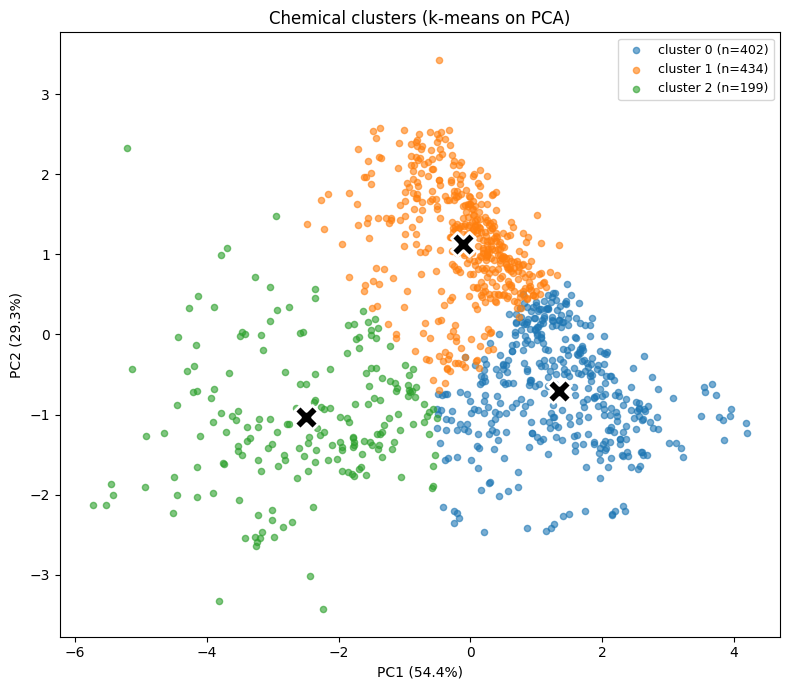

In [9]:
# fig_nb02_clusters: PCA biplot colored by cluster ID
fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.cm.tab10
for cid in sorted(df['chemical_cluster'].unique()):
    mask = df['chemical_cluster'] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, alpha=0.6,
               color=cmap(cid), label=f'cluster {cid} (n={mask.sum()})')
# Centroids
for cid in sorted(df['chemical_cluster'].unique()):
    centroid = X_pca[df['chemical_cluster']==cid].mean(axis=0)
    ax.scatter(centroid[0], centroid[1], marker='X', s=300, color='black', edgecolor='white', linewidth=2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Chemical clusters (k-means on PCA)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'fig_nb02_clusters.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

**Figure interpretation (fig_nb02_clusters):** The k-means clusters
separate the training opx into chemically distinct populations. The
centroid-chemistry + P-T table below assigns each cluster a petrologic
label (primitive basaltic, decompression residue, evolved/depleted, etc.).
These labels are used downstream in NB05 for LOSO stress testing - holding
one cluster out and retraining tests how well the model generalizes across
magmatic regimes, not just across random splits.

In [10]:
# Cluster summary
summary = df.groupby('chemical_cluster').agg(
    n=('chemical_cluster', 'size'),
    T_mean=('T_C', 'mean'),
    T_std=('T_C', 'std'),
    P_mean=('P_kbar', 'mean'),
    P_std=('P_kbar', 'std'),
    SiO2_mean=('SiO2', 'mean'),
    Mg_num_mean=('Mg_num', 'mean'),
)
print(summary.round(2))

                    n   T_mean   T_std  P_mean  P_std  SiO2_mean  Mg_num_mean
chemical_cluster                                                             
0                 402  1263.95  186.36   16.43  18.20      55.99        88.94
1                 434  1302.35  146.58   16.08   8.97      53.78        87.93
2                 199  1034.83  150.96    7.26   6.09      51.89        66.33


In [11]:
# Phase 2R.5 (v6): assign petrologic names to the k-means clusters.
# Rules are applied to the cluster centroid chemistry + mean P/T. Note
# Mg_num is stored on a 0-100 (mol%) scale, so thresholds are scaled
# accordingly. The canonical cleaned table is rewritten so NB03/NB05/NB08
# pick up the `cluster_name` column without refitting.
def _label_cluster(row):
    T = row['T_mean']; P = row['P_mean']
    Si = row['SiO2_mean']; Mg = row['Mg_num_mean']
    # Low-Mg, shallow, cooler -> differentiated
    if Mg < 75 or T < 1100:
        return 'evolved/depleted'
    # High-Mg and deep split by SiO2: low-Si = basaltic melt residue,
    # high-Si = decompression-melted harzburgitic residue.
    if P >= 12 and Si < 55:
        return 'primitive basaltic'
    if P >= 12 and Si >= 55:
        return 'decompression residue'
    return 'intermediate'

_name_map = summary.apply(_label_cluster, axis=1).to_dict()
df['cluster_name'] = df['chemical_cluster'].map(_name_map)

print('Cluster labels assigned:')
_label_tbl = (df.groupby(['chemical_cluster', 'cluster_name'])
                .size().reset_index(name='n')
                .sort_values('chemical_cluster'))
print(_label_tbl.to_string(index=False))


Cluster labels assigned:
 chemical_cluster          cluster_name   n
                0 decompression residue 402
                1    primitive basaltic 434
                2      evolved/depleted 199


In [12]:
# Save with cluster assignments + petrologic labels so the cleaning output
# from NB01 (`opx_clean_core.parquet`) is not overwritten. Downstream
# notebooks read this clustered file for the `chemical_cluster` +
# `cluster_name` columns used by NB03 stratification and NB05 LOSO.
df.to_parquet(DATA_PROC / 'opx_clean_core_with_clusters.parquet')
print('Saved opx_clean_core_with_clusters.parquet with '
      'chemical_cluster + cluster_name columns')
print(f'  cluster_name unique: {sorted(df["cluster_name"].dropna().unique())}')
print('\n=== NB02 (v6) COMPLETE ===')


Saved opx_clean_core_with_clusters.parquet with chemical_cluster + cluster_name columns
  cluster_name unique: ['decompression residue', 'evolved/depleted', 'primitive basaltic']

=== NB02 (v6) COMPLETE ===
